
--- Starting LSTM Consumption Forecasting ---
--- With Population and Income Growth as Input Features ---
Training data: 96 months (2015-01-01 00:00:00 to 2022-12-01 00:00:00)
Test data: 36 months (2023-01-01 00:00:00 to 2025-12-01 00:00:00)

Testing: Neurons=64, LR=0.01, Layers=1
Input shape: (look_back=6, features=3)


MAPE: 0.09%

Testing: Neurons=64, LR=0.01, Layers=2
Input shape: (look_back=6, features=3)
MAPE: 0.05%

Testing: Neurons=64, LR=0.001, Layers=1
Input shape: (look_back=6, features=3)
MAPE: 0.08%

Testing: Neurons=64, LR=0.001, Layers=2
Input shape: (look_back=6, features=3)
MAPE: 0.08%

Testing: Neurons=128, LR=0.01, Layers=1
Input shape: (look_back=6, features=3)
MAPE: 0.05%

Testing: Neurons=128, LR=0.01, Layers=2
Input shape: (look_back=6, features=3)
MAPE: 0.05%

Testing: Neurons=128, LR=0.001, Layers=1
Input shape: (look_back=6, features=3)
MAPE: 0.07%

Testing: Neurons=128, LR=0.001, Layers=2
Input shape: (look_back=6, features=3)
MAPE: 0.06%

Testing: Neurons=2

C:\Users\E124796\AppData\Local\Temp\2\ipykernel_23340\1656718974.py:256: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  save_model(best_model, 'best_lstm_model-multi.h5')


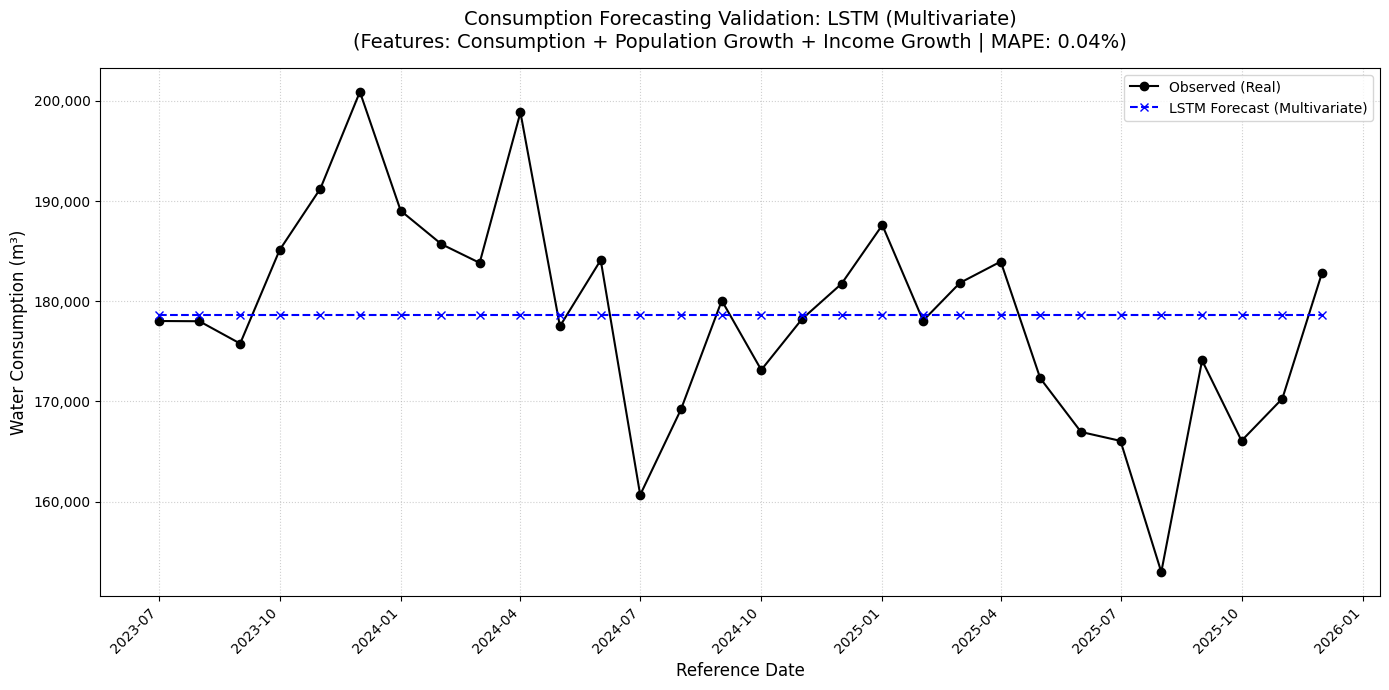

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import tensorflow as tf
import os
import random
from keras.regularizers import L1L2
from keras.models import save_model
import joblib

# ==========================================
# Reproducibility Configuration (Frozen Seeds)
# ==========================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ==========================================
# 1.1 Growth Rates Vectors (2016-2025)
# ==========================================
taxas_crescimento_mensal = [
    0.00034,  # 2016
    0.00034,  # 2017
    0.00035,  # 2018
    0.00034,  # 2019
    0.00032,  # 2020
    0.00030,  # 2021
    0.00029,  # 2022
    0.00027,  # 2023
    0.00025,  # 2024
    0.00023   # 2025
]

percentuais_aumento_renda = [
    -0.040694617,  # 2016
    0.005083616,   # 2017
    0.005261762,   # 2018
    0.009585339,   # 2019
    -0.045615004,  # 2020
    0.039183815,   # 2021
    0.021387542,   # 2022
    0.004332235,   # 2023
    0.045954924,   # 2024
    0.011194       # 2025
]

# Custom function to calculate MAPE as loss
def mape_loss(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    return tf.reduce_mean(tf.abs((y_true - y_pred) / y_true)) * 100

def create_multivariate_dataset(data, look_back=1):
    """
    Converts multivariate time series data into a supervised learning format.
    data: DataFrame with columns ['consumption', 'pop_growth', 'income_growth']
    Returns X (features) and Y (target)
    """
    X, Y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back)].values)
        Y.append(data.iloc[i + look_back]['consumption'])
    return np.array(X), np.array(Y)

# Function to build a dynamic LSTM model for multivariate input
def build_dynamic_model_multivariate(input_shape, neurons=100, learning_rate=0.01, n_layers=2):
    model = Sequential()
    
    # Add the first LSTM layer
    model.add(LSTM(
        neurons, 
        return_sequences=(n_layers > 1), 
        input_shape=input_shape,
        kernel_regularizer=L1L2(l1=1e-5, l2=1e-4)
    ))
    model.add(Dropout(0.2))
    
    # Add intermediate LSTM layers
    for i in range(1, n_layers):
        return_seq = (i != n_layers - 1)
        model.add(LSTM(
            neurons // (2 ** i),  
            return_sequences=return_seq,
            kernel_regularizer=L1L2(l1=1e-5, l2=1e-4)
        ))
        model.add(Dropout(0.2))
    
    # Final dense layers
    model.add(Dense(25, activation='relu'))
    model.add(Dense(1))
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(loss=mape_loss, optimizer=optimizer)
    return model

# Main prediction and plotting function
def prever_e_plotar(caminho_arquivo):
    print("--- Starting LSTM Consumption Forecasting ---")
    print("--- With Population and Income Growth as Input Features ---")
    
    # ==========================================
    # 2. Data Loading and Preprocessing
    # ==========================================
    df = pd.read_csv(caminho_arquivo, sep=';')
    df['AM_REFERENCIA'] = pd.to_datetime(df['AM_REFERENCIA'], format='%Y%m')
    df_aggregated = df.groupby('AM_REFERENCIA')['HCLQTCON'].sum().reset_index()
    df_aggregated = df_aggregated.sort_values(by='AM_REFERENCIA')
    
    dates = df_aggregated['AM_REFERENCIA']
    consumption = df_aggregated['HCLQTCON'].values
    
    # ==========================================
    # 3. Create Multivariate Dataset
    # ==========================================
    pop_growth_monthly = []
    inc_growth_monthly = []
    
    # 2015 (use 2016 rates as baseline)
    pop_growth_monthly.extend([taxas_crescimento_mensal[0]] * 12)
    inc_growth_monthly.extend([percentuais_aumento_renda[0]] * 12)
    
    # 2016-2025
    for i in range(10):
        pop_growth_monthly.extend([taxas_crescimento_mensal[i]] * 12)
        inc_growth_monthly.extend([percentuais_aumento_renda[i]] * 12)
    
    n_months = len(consumption)
    pop_growth_monthly = pop_growth_monthly[:n_months]
    inc_growth_monthly = inc_growth_monthly[:n_months]
    
    df_multivariate = pd.DataFrame({
        'date': dates,
        'consumption': consumption,
        'pop_growth': pop_growth_monthly,
        'income_growth': inc_growth_monthly
    })
    
    # ==========================================
    # 4. Data Normalization
    # ==========================================
    scaler = MinMaxScaler(feature_range=(0, 1))
    features_to_scale = ['consumption', 'pop_growth', 'income_growth']
    df_multivariate[features_to_scale] = scaler.fit_transform(
        df_multivariate[features_to_scale]
    )
    
    # Train-Test Split (Chronological)
    train_mask = (df_multivariate['date'] >= '2015-01-01') & (df_multivariate['date'] <= '2022-12-01')
    test_mask = (df_multivariate['date'] >= '2023-01-01') & (df_multivariate['date'] <= '2025-12-01')
    
    train_data = df_multivariate[train_mask].copy()
    test_data = df_multivariate[test_mask].copy()
    
    print(f"Training data: {len(train_data)} months ({train_data['date'].min()} to {train_data['date'].max()})")
    print(f"Test data: {len(test_data)} months ({test_data['date'].min()} to {test_data['date'].max()})")

    look_back = 6
    
    # Create dataset with all features
    X_train, Y_train = create_multivariate_dataset(
        train_data[['consumption', 'pop_growth', 'income_growth']], 
        look_back
    )
    X_test, Y_test = create_multivariate_dataset(
        test_data[['consumption', 'pop_growth', 'income_growth']], 
        look_back
    )
    
    if len(X_train) == 0 or len(X_test) == 0:
        raise ValueError("Insufficient data for training or testing.")
    
    # Reshape for LSTM: (samples, time steps, features)
    # X_train shape: (samples, look_back, 3 features)
    # X_test shape: (samples, look_back, 3 features)
    
    # ==========================================
    # 5. Hyperparameter Grid Search
    # ==========================================
    params_grid = {
        'neurons': [64, 128, 256],
        'learning_rate': [0.01, 0.001],
        'n_layers': [1, 2],
        'epochs': [50, 100, 200],
        'batch_size': [1, 4]
    }

    best_mape = float('inf')
    best_model = None
    best_params = {}
    best_scaler = None

    for neurons in params_grid['neurons']:
        for lr in params_grid['learning_rate']:
            for n_layers in params_grid['n_layers']:
                print(f"\nTesting: Neurons={neurons}, LR={lr}, Layers={n_layers}")
                print(f"Input shape: (look_back={look_back}, features=3)")
                
                model = build_dynamic_model_multivariate(
                    input_shape=(X_train.shape[1], X_train.shape[2]),  # (look_back, 3 features)
                    neurons=neurons,
                    learning_rate=lr,
                    n_layers=n_layers
                )
                
                early_stop = EarlyStopping(monitor='loss', patience=10)
                
                history = model.fit(
                    X_train, Y_train,
                    epochs=params_grid['epochs'][1],
                    batch_size=params_grid['batch_size'][0],
                    verbose=0,
                    callbacks=[early_stop]
                )
                
                predictions_scaled = model.predict(X_test, verbose=0).flatten()
                
                # Inverse transform predictions
                predictions_dummy = np.zeros((len(predictions_scaled), 3))
                predictions_dummy[:, 0] = predictions_scaled
                predictions = scaler.inverse_transform(predictions_dummy)[:, 0]
                
                # Inverse transform actual values
                Y_test_dummy = np.zeros((len(Y_test), 3))
                Y_test_dummy[:, 0] = Y_test
                Y_test_original = scaler.inverse_transform(Y_test_dummy)[:, 0]
                
                mape_value = mape(Y_test_original, predictions)
                print(f"MAPE: {mape_value:.2f}%")
                
                if mape_value < best_mape:
                    best_mape = mape_value
                    best_model = model
                    best_params = {
                        'neurons': neurons,
                        'learning_rate': lr,
                        'n_layers': n_layers,
                        'epochs': len(history.history['loss'])
                    }
                    best_scaler = scaler

    # ==========================================
    # 6. Save Best Model
    # ==========================================
    print("\nBest Parameters Found:")
    print(best_params)
    print(f"Best MAPE: {best_mape:.2f}%")

    save_model(best_model, 'best_lstm_model-multi.h5')
    joblib.dump(best_scaler, 'scaler_itapua-multi.save')
    print("Model and scaler saved successfully!")

    # ==========================================
    # 7. Final Predictions
    # ==========================================
    final_predictions_scaled = best_model.predict(X_test, verbose=0).flatten()
    
    predictions_dummy = np.zeros((len(final_predictions_scaled), 3))
    predictions_dummy[:, 0] = final_predictions_scaled
    final_predictions = best_scaler.inverse_transform(predictions_dummy)[:, 0]

    # Get dates corresponding to the test period
    test_dates = test_data['date'].iloc[look_back:].values
    
    # Comparison DataFrame
    Y_test_original = scaler.inverse_transform(Y_test_dummy)[:, 0]
    comparison_df = pd.DataFrame({
        'Date': test_dates,
        'Actual Value': Y_test_original,
        'Predicted Value': final_predictions
    })

    print("\nFinal Comparison Table:")
    print(comparison_df)

    # ==========================================
    # 8. Visualization
    # ==========================================
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.plot(comparison_df['Date'], comparison_df['Actual Value'], 
            label='Observed (Real)', color='black', marker='o', linestyle='-')
    ax.plot(comparison_df['Date'], comparison_df['Predicted Value'], 
            label=f'LSTM Forecast (Multivariate)', color='blue', marker='x', linestyle='--')

    ax.set_title(f"Consumption Forecasting Validation: LSTM (Multivariate)\n"
                 f"(Features: Consumption + Population Growth + Income Growth | MAPE: {best_mape:.2f}%)", 
                 fontsize=14, pad=15)
    ax.set_ylabel('Water Consumption (m³)', fontsize=12)
    ax.set_xlabel('Reference Date', fontsize=12)
    
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()
    
    # Save to PDF
    output_dir = os.path.join(os.path.dirname(caminho_arquivo), '..', 'figuras')
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    save_path = os.path.join(output_dir, 'figure-lstm-forecast-validation-multi.pdf')
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    plt.show()

# Main Execution
if __name__ == "__main__":
    path = '..'
    caminho_arquivo = os.path.join(path, 'includes', 'dados', 'Tabela_consumo_Itapua_120m.csv')
    prever_e_plotar(caminho_arquivo)

In [3]:
from tensorflow.keras.models import load_model

# Carregar e exibir a arquitetura do melhor modelo LSTM
model = load_model('best_lstm_model-multi.h5', compile=False)

print("=" * 50)
print("ARQUITETURA DO MELHOR MODELO LSTM")
print("=" * 50)
model.summary()
print("=" * 50)



ARQUITETURA DO MELHOR MODELO LSTM
Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_13 (LSTM)              (None, 6, 256)            266240    
                                                                 
 dropout_13 (Dropout)        (None, 6, 256)            0         
                                                                 
 lstm_14 (LSTM)              (None, 128)               197120    
                                                                 
 dropout_14 (Dropout)        (None, 128)               0         
                                                                 
 dense_18 (Dense)            (None, 25)                3225      
                                                                 
 dense_19 (Dense)            (None, 1)                 26        
                                                                 
Total params: 4666